In [8]:
import logging
from tqdm.notebook import tqdm
import pandas as pd
import numpy as np
import pandas as pd
import os
import logging
from tqdm.notebook import tqdm
import pandas as pd
import numpy as np
import pandas as pd
import os
import pickle
from datetime import datetime
from ts_toolkit.pipeline.runner import TsPipeline
from ts_toolkit.pipeline.utils import load_config, forecast_output_saver
from ts_toolkit.pipeline.viz_utils import (
    DISTRIBUTIONS, Chronos2_baselines, METRIC_LIST, colors, 
    compute_improve, generate_final_table, groupby, combine_results
)

os.environ["CUDA_VISIBLE_DEVICES"] = "1"
logging.basicConfig(level=logging.INFO)

In [9]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Individual Results

In [10]:
experiment_name = 'CopyPaste'

polished_path = f"results/polished_outputs/{datetime.now().strftime('%Y%m%d_%H%M%S')}/{experiment_name}/forecast_outputs.pkl"
os.makedirs(os.path.dirname(polished_path), exist_ok=True)

for baseline in [True, False]: # Run both baseline and finetuned models
    config_dict = {
        "experiment_name": "tmp",
        "paths": {
            "storage_path": "data/simpletime/datasets_100",
            "output_path": "tmp_results"
        },
        "forecaster": {
            "name": "MedianEnsemble",
            "max_length": 512,
            "models": [{"name": "Chronos2", "params": {"batch_size": 64}} if baseline else {
                "name": "Chronos2", "params": {"repo_id": "results/finetuned_models/chronos2/20260212_113124/finetuned-ckpt", "batch_size": 64}
            }],
            "alias": f"Chronos2{'-Finetuned' if not baseline else ''}-{experiment_name}-Simpletime" # An identifier for your ensemble
        },
        "evaluation": {
            "to_univariate": False,
            "show_plot": False,
            "eval_substr": "dim0"
        },
        "datasets": [
            {"name": f"multivariate_lagged/{trend}", "term": "short"} for trend in DISTRIBUTIONS["I.I.D. White Noise"] + DISTRIBUTIONS["Stochastic Drift/Shocks"]
        ]
    }

    config = load_config(config_dict=config_dict) # config_path

    # --- Set up the evaluation pipeline ---
    pipeline = TsPipeline(config)
    # print(pipeline.get_forecast_horizons())
    pipeline.run(skip_existing=False, num_plots=1)
    # pipeline.get_results()
    output_list = pipeline.output_forecast_generator()
    forecast_output_saver(pipeline, "Multivariate", "Chronos2" if baseline else "Chronos2-Finetuned", polished_path)

    print(polished_path)

INFO:ts_toolkit.pipeline.runner:   - Results will be saved to: /home/nafiseh/GitHub/timeseries-research/tmp_results/tmp_20260214-121008/Chronos2-CopyPaste-Simpletime
INFO:ts_toolkit.pipeline.runner:   - Datasets will be loaded from: /home/nafiseh/GitHub/timeseries-research/data/simpletime/datasets_100

INFO:ts_toolkit.pipeline.runner:
--- Starting Evaluation ---


Evaluating Datasets:   0%|          | 0/15 [00:00<?, ?it/s]

INFO:ts_toolkit.pipeline.eval:Input: 2000-09-12T00:00:00.000000, label: 2000-09-12T00:00:00.000000, prediction length: 30
100it [00:00, 905.74it/s]
INFO:ts_toolkit.pipeline.eval:Results for multivariate_lagged/normal have been written to /home/nafiseh/GitHub/timeseries-research/tmp_results/tmp_20260214-121008/Chronos2-CopyPaste-Simpletime/all_results.csv
INFO:ts_toolkit.pipeline.eval:Config has been written to /home/nafiseh/GitHub/timeseries-research/tmp_results/tmp_20260214-121008/Chronos2-CopyPaste-Simpletime/tmp_20260214-121008_config.yaml
INFO:ts_toolkit.pipeline.eval:Input: 2000-09-12T00:00:00.000000, label: 2000-09-12T00:00:00.000000, prediction length: 30
100it [00:00, 967.06it/s]
INFO:ts_toolkit.pipeline.eval:Results for multivariate_lagged/uniform have been written to /home/nafiseh/GitHub/timeseries-research/tmp_results/tmp_20260214-121008/Chronos2-CopyPaste-Simpletime/all_results.csv
INFO:ts_toolkit.pipeline.eval:Config has been written to /home/nafiseh/GitHub/timeseries-rese

results/polished_outputs/20260214_121008/CopyPaste/forecast_outputs.pkl


Evaluating Datasets:   0%|          | 0/15 [00:00<?, ?it/s]

INFO:ts_toolkit.pipeline.eval:Input: 2000-09-12T00:00:00.000000, label: 2000-09-12T00:00:00.000000, prediction length: 30
100it [00:00, 920.39it/s]
INFO:ts_toolkit.pipeline.eval:Results for multivariate_lagged/normal have been written to /home/nafiseh/GitHub/timeseries-research/tmp_results/tmp_20260214-121055/Chronos2-Finetuned-CopyPaste-Simpletime/all_results.csv
INFO:ts_toolkit.pipeline.eval:Config has been written to /home/nafiseh/GitHub/timeseries-research/tmp_results/tmp_20260214-121055/Chronos2-Finetuned-CopyPaste-Simpletime/tmp_20260214-121055_config.yaml
INFO:ts_toolkit.pipeline.eval:Input: 2000-09-12T00:00:00.000000, label: 2000-09-12T00:00:00.000000, prediction length: 30
100it [00:00, 904.46it/s]
INFO:ts_toolkit.pipeline.eval:Results for multivariate_lagged/uniform have been written to /home/nafiseh/GitHub/timeseries-research/tmp_results/tmp_20260214-121055/Chronos2-Finetuned-CopyPaste-Simpletime/all_results.csv
INFO:ts_toolkit.pipeline.eval:Config has been written to /home/

results/polished_outputs/20260214_121008/CopyPaste/forecast_outputs.pkl


In [11]:
results = pipeline.get_results()
agg_results = combine_results(Chronos2_baselines | {f"Chronos2 (Finetuned - {experiment_name})": f"{pipeline.config.paths.output_path}/Chronos2-Finetuned-{experiment_name}-Simpletime"})
df_final = generate_final_table(agg_results, f"Chronos2 (Finetuned - {experiment_name})")
df_final = df_final.reset_index()

Chronos2 (Baseline) - Multivariate: results/Chronos2-Multivariate-SimpleTime_20260210-134650/Chronos2-Multivariate-SimpleTime
Chronos2 (Finetuned - CopyPaste): /home/nafiseh/GitHub/timeseries-research/tmp_results/tmp_20260214-121055/Chronos2-Finetuned-CopyPaste-Simpletime


Number of datasets to plot: 15
multivariate_lagged/normal: normal_sample_000037 selected.
multivariate_lagged/uniform: uniform_sample_000008 selected.
multivariate_lagged/poisson: poisson_sample_000038 selected.
multivariate_lagged/binary: binary_sample_000067 selected.
multivariate_lagged/student_t: student_t_sample_000008 selected.
multivariate_lagged/lognormal: lognormal_sample_000042 selected.
multivariate_lagged/laplace: laplace_sample_000005 selected.
multivariate_lagged/cauchy: cauchy_sample_000093 selected.
multivariate_lagged/skew_normal: skew_normal_sample_000085 selected.
multivariate_lagged/random_walk: random_walk_sample_000090 selected.
multivariate_lagged/piecewise_constant: piecewise_constant_sample_000053 selected.
multivariate_lagged/gbm: gbm_sample_000037 selected.
multivariate_lagged/intermittent: intermittent_sample_000007 selected.
multivariate_lagged/impulse: impulse_sample_000088 selected.
multivariate_lagged/logistic: logistic_sample_000040 selected.


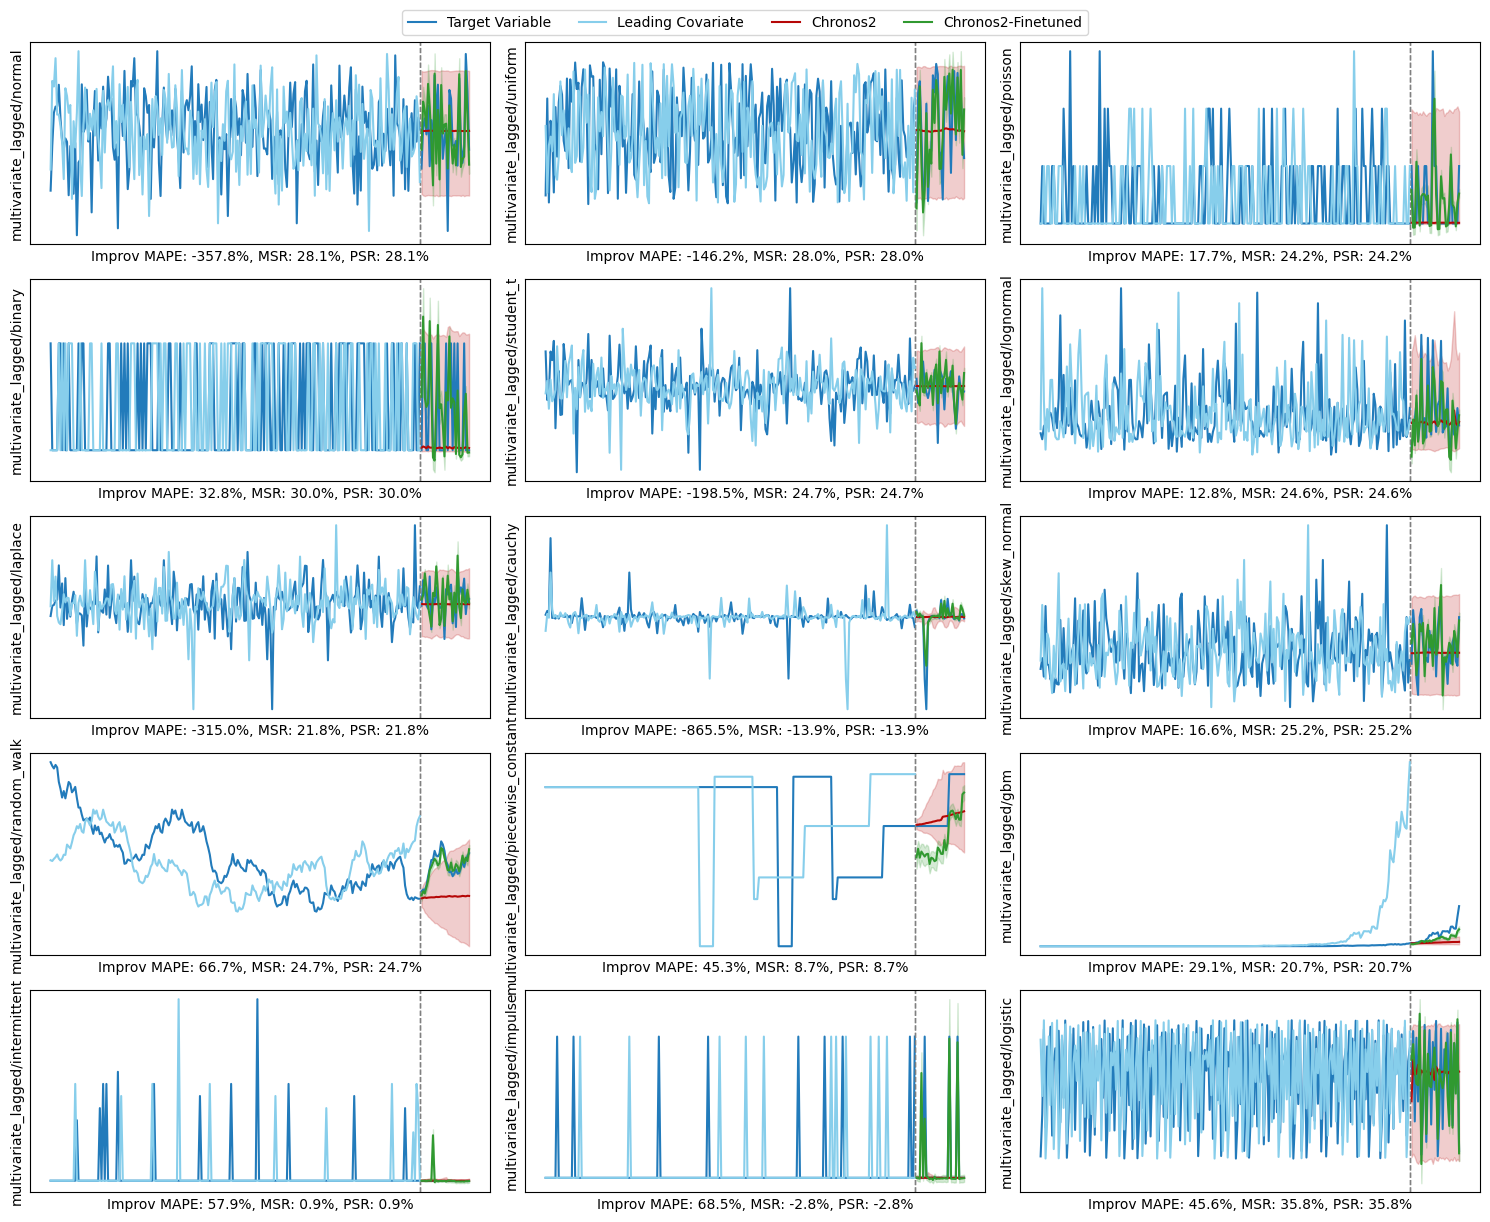

In [14]:
import pickle 
from ts_toolkit.pipeline.visualization import polished_grid_plot
from ts_toolkit.pipeline.viz_utils import colors
from matplotlib import pyplot as plt

with open(polished_path, "rb") as f:
    output_data = pickle.load(f)
    
polished_grid_plot(
    output_data, colors, shade=True, selected_data_ids={}, caption_df=df_final, 
    num_fig_cols=3, figsize=(15, 12), bbox_to_anchor=(0.5, 1.02),
    save_path=f'results_shared/TSALM2025_paper/ft_experiments_copypaste.pdf'
)


In [13]:
from ts_toolkit.pipeline.viz_utils import save_latex_table

df_final = df_final.rename(columns={x: (x[0].replace('eval_metrics/', '').replace('[512]','' ), x[1]) for x in df_final.columns})
df_output = df_final.drop(columns=['dataset', 'variate', 'num_variates', 'var_mode']).sort_values(by=['distribution-family'])
# set the 'distribution-family' column first
cols = df_output.columns.tolist()
cols = [col for col in cols if col[0] != 'distribution-family']
cols = [('distribution-family', '')] + cols
df_output = df_output[cols].round(2)
display(df_output)

latex_code = save_latex_table(df_output).replace(
    'Chronos2 (Baseline)', 'Base'
).replace('Chronos2 (Finetuned - CopyPaste)', 'Finetuned').replace('I.I.D. White Noise', 'I.I.D. Noise').replace(
    'Stochastic Drift/Shocks', 'Drift/Shocks'
)
print(latex_code)

final_agg_df = df_final[[col for col in df_final.columns if 'eval_metrics' in col[0]]].median().round(2)
display(final_agg_df)
print(save_latex_table(final_agg_df.to_frame().T))

/tmp/ipykernel_2527316/1091172944.py:4: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df_output = df_final.drop(columns=['dataset', 'variate', 'num_variates', 'var_mode']).sort_values(by=['distribution-family'])


distribution-family        distribution eval_metrics/MAPE[0.5]  \
model                                                 Chronos2 (Baseline)   
0           I.I.D. White Noise              binary                   0.25   
1           I.I.D. White Noise              cauchy                   2.37   
5           I.I.D. White Noise             laplace                   1.53   
7           I.I.D. White Noise           lognormal                   0.52   
8           I.I.D. White Noise              normal                   1.22   
10          I.I.D. White Noise             poisson                   0.52   
12          I.I.D. White Noise         skew_normal                   9.71   
13          I.I.D. White Noise           student_t                   1.29   
14          I.I.D. White Noise             uniform                   1.19   
2      Stochastic Drift/Shocks                 gbm                   0.58   
3      Stochastic Drift/Shocks             impulse                   1.00   
4      Stochastic Drift/Shocks        intermittent                   1.00   
6      Stochastic Drift/Shocks            logistic                   0.88   
9      Stochastic Drift/Shocks  piecewise_constant                   1.92   
11     Stochastic Drift/Shocks         random_walk                   3.12   

                                                \
model Chronos2 (Finetuned - CopyPaste) %Improv   
0                                 0.17   32.83   
1                                22.89 -865.51   
5                                 6.35 -314.98   
7                                 0.45   12.75   
8                                 5.58 -357.85   
10                                0.43   17.68   
12                                8.10   16.57   
13                                3.86 -198.50   
14                                2.93 -146.16   
2                                 0.41   29.14   
3                                 0.31   68.49   
4                                 0.42   57.92   
6                                 0.48   45.60   
9                                 1.05   45.29   
11                                1.04   66.75   

      eval_metrics/MeanSkillRatio[0.5][512]                                   \
model                   Chronos2 (Baseline) Chronos2 (Finetuned - CopyPaste)   
0                                      0.77                             0.54   
1                                      0.86                             0.98   
5                                      1.00                             0.78   
7                                      0.94                             0.71   
8                                      1.00                             0.72   
10                                     0.98                             0.74   
12                                     0.99                             0.74   
13                                     1.00                             0.75   
14                                     1.00                             0.72   
2                                      0.92                             0.73   
3                                      0.52                             0.53   
4                                      0.58                             0.57   
6                                      0.99                             0.63   
9                                      0.48                             0.44   
11                                     0.41                             0.31   

              eval_metrics/PersistenceSkillRatio[0.5]  \
model %Improv                     Chronos2 (Baseline)   
0       30.02                                    0.73   
1      -13.94                                    0.82   
5       21.78                                    0.63   
7       24.58                                    0.73   
8       28.13                                    0.74   
10      24.22                                    0.72   
12      25.17                    

ValueError: unsupported format character '$' (0x24) at index 6

In [ ]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

## Aggregate Results

In [ ]:
# results_repertoire_raw = {
#     "Chronos2 (Baseline) - Multivariate": "results/Chronos2-Multivariate-SimpleTime_20260210-134650/Chronos2-Multivariate-SimpleTime",
#     "Chronos2 (Baseline) - Univariate": "results/Chronos2-Univariate-SimpleTime_20260210-135127/Chronos2-Univariate-SimpleTime",
#     # "ToTo - Multivariate": "results/",
#     # "ToTo - Univariate": "results/",
#     # "Moirai - Multivariate": "results/simpleTSbench_Multivariate_Full_20260203-104244/Moirai-Multivariate-Full-SimpleTSBench",
#     # "Moirai - Univariate": "",
#     # 'Chronos2 (Finetuned - Norm) - Multivariate - best-model': 'results/Chronos2-FineTuned-Norm-Multivariate-SimpleTime-best_model_20260210-134949/Chronos2-FineTuned-Norm-Multivariate-SimpleTime-best_model', # bast model based on all datasets
#     'Chronos2 (Finetuned - Norm) - Multivariate': 'results/Chronos2-FineTuned-Norm-Multivariate-SimpleTime-100k_steps_20260210-135421/Chronos2-FineTuned-Norm-Multivariate-SimpleTime-100k_steps', 
#     # 'Chronos2 (Finetuned - Norm) - Univariate - best-model': 'results/Chronos2-FineTuned-Norm-Univariate-SimpleTime-best_model_20260210-135846/Chronos2-FineTuned-Norm-Univariate-SimpleTime-best_model', # bast model based on all datasets
#     'Chronos2 (Finetuned - Norm) - Univariate': 'results/Chronos2-FineTuned-Norm-Univariate-SimpleTime-100k_steps_20260210-140246/Chronos2-FineTuned-Norm-Univariate-SimpleTime-100k_steps',
#     # 'Chronos2 (Finetuned - CopyPaste) - Multivariate - best-model': 'results/Chronos2-FineTuned-CopyPaste-Multivariate-SimpleTime-best_model_20260210-134835/Chronos2-FineTuned-CopyPaste-Multivariate-SimpleTime-best_model', # bast model based on all datasets
#     'Chronos2 (Finetuned - CopyPaste) - Multivariate': 'results/Chronos2-FineTuned-CopyPaste-Multivariate-SimpleTime-100k_steps_20260210-135310/Chronos2-FineTuned-CopyPaste-Multivariate-SimpleTime-100k_steps',
#     # 'Chronos2 (Finetuned - CopyPaste) - Univariate - best-model': 'results/Chronos2-FineTuned-CopyPaste-Univariate-SimpleTime-best_model_20260210-135745/Chronos2-FineTuned-CopyPaste-Univariate-SimpleTime-best_model', # bast model based on all datasets
#     'Chronos2 (Finetuned - CopyPaste) - Univariate': 'results/Chronos2-FineTuned-CopyPaste-Univariate-SimpleTime-100k_steps_20260210-140150/Chronos2-FineTuned-CopyPaste-Univariate-SimpleTime-100k_steps',
#     # 'Chronos2 (Finetuned - All) - Multivariate - best-model': 'results/Chronos2-FineTuned-All-Multivariate-SimpleTime-best_model_20260210-134816/Chronos2-FineTuned-All-Multivariate-SimpleTime-best_model', # best model based on multivar lagged on "I.I.D. White Noise" and "Stochastic Drift/Shocks" bundles
#     'Chronos2 (Finetuned - All) - Multivariate': 'results/Chronos2-FineTuned-All-Multivariate-SimpleTime-100k_steps_20260210-135251/Chronos2-FineTuned-All-Multivariate-SimpleTime-100k_steps',
#     # 'Chronos2 (Finetuned - All) - Univariate - best-model': 'results/Chronos2-FineTuned-All-Univariate-SimpleTime-best_model_20260210-135723/Chronos2-FineTuned-All-Univariate-SimpleTime-best_model', # best model based on multivar lagged on "I.I.D. White Noise" and "Stochastic Drift/Shocks" bundles
#     'Chronos2 (Finetuned - All) - Univariate': 'results/Chronos2-FineTuned-All-Univariate-SimpleTime-100k_steps_20260210-140126/Chronos2-FineTuned-All-Univariate-SimpleTime-100k_steps',
#     'Chronos2 (Finetuned - Bias) - Multivariate': 'results/Chronos2-FineTuned-Bias-Multivariate-SimpleTime-100k_steps_20260210-134828/Chronos2-FineTuned-Bias-Multivariate-SimpleTime-100k_steps',
#     'Chronos2 (Finetuned - Bias) - Univariate': 'results/Chronos2-FineTuned-Bias-Univariate-SimpleTime-100k_steps_20260210-135302/Chronos2-FineTuned-Bias-Univariate-SimpleTime-100k_steps',
# }

# # 10k steps finetuning
# results_repertoire_raw = {
#     "Chronos2 (Baseline) - Multivariate": "results/Chronos2-Multivariate-SimpleTime_20260210-134650/Chronos2-Multivariate-SimpleTime",
#     "Chronos2 (Baseline) - Univariate": "results/Chronos2-Univariate-SimpleTime_20260210-135127/Chronos2-Univariate-SimpleTime",
#     'Chronos2 (Finetuned - Bias) - Multivariate': 'results/Chronos2-FineTuned-Bias-Multivariate-SimpleTime_20260211-154413/Chronos2-FineTuned-Bias-Multivariate-SimpleTime',
#     'Chronos2 (Finetuned - Bias) - Univariate': 'results/Chronos2-FineTuned-Bias-Univariate-SimpleTime_20260211-154859/Chronos2-FineTuned-Bias-Univariate-SimpleTime',
#     'Chronos2 (Finetuned - Norm) - Multivariate': 'results/Chronos2-FineTuned-Norm-Multivariate-SimpleTime_20260211-154515/Chronos2-FineTuned-Norm-Multivariate-SimpleTime', 
#     'Chronos2 (Finetuned - Norm) - Univariate': 'results/Chronos2-FineTuned-Norm-Univariate-SimpleTime_20260211-155001/Chronos2-FineTuned-Norm-Univariate-SimpleTime',
#     'Chronos2 (Finetuned - CopyPaste) - Multivariate': 'results/Chronos2-FineTuned-CopyPaste-Multivariate-SimpleTime_20260211-154609/Chronos2-FineTuned-CopyPaste-Multivariate-SimpleTime',
#     'Chronos2 (Finetuned - CopyPaste) - Univariate': 'results/Chronos2-FineTuned-CopyPaste-Univariate-SimpleTime_20260211-155059/Chronos2-FineTuned-CopyPaste-Univariate-SimpleTime',
#     'Chronos2 (Finetuned - All) - Multivariate': 'results/Chronos2-FineTuned-All-Multivariate-SimpleTime_20260211-161928/Chronos2-FineTuned-All-Multivariate-SimpleTime',
#     'Chronos2 (Finetuned - All) - Univariate': 'results/Chronos2-FineTuned-All-Univariate-SimpleTime_20260211-162356/Chronos2-FineTuned-All-Univariate-SimpleTime',
# }

# ~100k steps finetuning
results_repertoire_raw = {
    "Chronos2 (Baseline) - Multivariate": "results/Chronos2-Multivariate-SimpleTime_20260210-134650/Chronos2-Multivariate-SimpleTime",
    "Chronos2 (Baseline) - Univariate": "results/Chronos2-Univariate-SimpleTime_20260210-135127/Chronos2-Univariate-SimpleTime",
    'Chronos2 (Finetuned - Bias) - Multivariate': 'results/Chronos2-FineTuned-Bias-Multivariate-SimpleTime_20260212-154222/Chronos2-FineTuned-Bias-Multivariate-SimpleTime',
    # 'Chronos2 (Finetuned - Bias) - Univariate': 'results/Chronos2-FineTuned-Bias-Univariate-SimpleTime_20260212-154802/Chronos2-FineTuned-Bias-Univariate-SimpleTime',
    'Chronos2 (Finetuned - Norm) - Multivariate': 'results/Chronos2-FineTuned-Norm-Multivariate-SimpleTime_20260212-132219/Chronos2-FineTuned-Norm-Multivariate-SimpleTime', 
    # 'Chronos2 (Finetuned - Norm) - Univariate': 'results/Chronos2-FineTuned-Norm-Univariate-SimpleTime_20260212-132752/Chronos2-FineTuned-Norm-Univariate-SimpleTime',
    # 'Chronos2 (Finetuned - CopyPaste) - Multivariate': 'results//Chronos2-FineTuned-CopyPaste-Multivariate-SimpleTime',
    # 'Chronos2 (Finetuned - CopyPaste) - Univariate': 'results//Chronos2-FineTuned-CopyPaste-Univariate-SimpleTime',
    # 'Chronos2 (Finetuned - All) - Multivariate': 'results//Chronos2-FineTuned-All-Multivariate-SimpleTime',
    # 'Chronos2 (Finetuned - All) - Univariate': 'results//Chronos2-FineTuned-All-Univariate-SimpleTime',
}


In [ ]:
agg_df = combine_results(results_repertoire_raw)

df_agg_results = agg_df.groupby(['model', 'variate', 'var_mode', 'distribution', 'distribution-family'])[[col for col in agg_df.columns if 'eval_metrics' in col and 'MAR' not in col and 'MBR' not in col]].mean()
df_agg_results = df_agg_results.rename(columns=lambda x: x.replace('eval_metrics/', '').replace('[512]','' ))
# show variate on columns rather than index
# show 2 decimal points even before e power, and avoid scientific notation for values less than 10
def format_value(x):
    if abs(x) < 10:
        return f'{x:.2f}'
    if abs(x) < 1000:
        return f'{x:.1f}'
    return f'{x:.1e}'


df_agg_results = df_agg_results.unstack(level=1)
# MULTI over UNI error Improvement
for metric, mode in df_agg_results.columns:
    df_agg_results[(metric, '%Improv')] = (df_agg_results[(metric, 'UNI')].values - df_agg_results[(metric, 'MULTI')].values) / df_agg_results[(metric, 'UNI')].values * 100

# sort columns to have uni>multi>%improv per metric
df_agg_results = df_agg_results.reindex(columns=[col for metric in sorted(set([col[0] for col in df_agg_results.columns])) for col in [(metric, 'UNI'), (metric, 'MULTI'), (metric, '%Improv')]])

display(df_agg_results.applymap(format_value))

Chronos2 (Baseline) - Multivariate: results/Chronos2-Multivariate-SimpleTime_20260210-134650/Chronos2-Multivariate-SimpleTime
Chronos2 (Baseline) - Univariate: results/Chronos2-Univariate-SimpleTime_20260210-135127/Chronos2-Univariate-SimpleTime
Chronos2 (Finetuned - Bias) - Multivariate: results/Chronos2-FineTuned-Bias-Multivariate-SimpleTime_20260212-154222/Chronos2-FineTuned-Bias-Multivariate-SimpleTime
Chronos2 (Finetuned - Bias) - Univariate: results/Chronos2-FineTuned-Bias-Univariate-SimpleTime_20260212-154802/Chronos2-FineTuned-Bias-Univariate-SimpleTime
Chronos2 (Finetuned - Norm) - Multivariate: results/Chronos2-FineTuned-Norm-Multivariate-SimpleTime_20260212-132219/Chronos2-FineTuned-Norm-Multivariate-SimpleTime
Chronos2 (Finetuned - Norm) - Univariate: results/Chronos2-FineTuned-Norm-Univariate-SimpleTime_20260212-132752/Chronos2-FineTuned-Norm-Univariate-SimpleTime


,dataset,variate,num_variates,model,eval_metrics/MeanAttractionRatio[0.5][512],eval_metrics/MeanBiasRatio[0.5][512],eval_metrics/PathVolatilityRatio[0.5][512],eval_metrics/PersistenceSkillRatio[0.5],eval_metrics/MeanSkillRatio[0.5][512],eval_metrics/NormalizedMeanBias[0.5],...,eval_metrics/MAPE[0.5],eval_metrics/sMAPE[0.5],eval_metrics/MSIS,eval_metrics/RMSE[mean],eval_metrics/NRMSE[mean],eval_metrics/ND[0.5],eval_metrics/mean_weighted_sum_quantile_loss,distribution-family,distribution,var_mode
0,multivariate_lagged/growing_sine/short,MULTI,2,Chronos2 (Baseline),1.068599,0.801000,1.072495,0.067597,0.078574,6.147022e-03,...,1.895141e-01,1.287282e-01,3.007669,2.137411e+01,1.671107e-01,7.861437e-02,5.974907e-02,Transient Dynamics,growing_sine,multivariate_lagged
1,multivariate_lagged/student_t/short,MULTI,2,Chronos2 (Baseline),13.793969,0.969667,26.199976,0.711258,0.998925,9.191062e-03,...,1.292361e+00,1.748795e+00,6.130846,1.623318e+00,1.481738e+00,1.006404e+00,8.142239e-01,I.I.D. White Noise,student_t,multivariate_lagged
2,multivariate_lagged/poisson/short,MULTI,2,Chronos2 (Baseline),4.576591,0.950000,24.791001,0.719821,0.977998,1.191770e-01,...,5.245162e-01,1.043336e+00,5.516562,1.245561e+00,8.070592e-01,5.901598e-01,4.507270e-01,I.I.D. White Noise,poisson,multivariate_lagged
3,multivariate_lagged/lognormal/short,MULTI,2,Chronos2 (Baseline),2.484265,0.891333,26.065159,0.733476,0.938895,1.949841e-01,...,5.192505e-01,4.164709e-01,5.371071,1.187308e+00,9.617800e-01,4.432631e-01,3.576225e-01,I.I.D. White Noise,lognormal,multivariate_lagged
4,multivariate_lagged/constant/short,MULTI,2,Chronos2 (Baseline),0.997638,0.206667,0.000000,0.192370,0.000384,-3.596756e-11,...,6.265648e-10,6.265648e-10,NaN,2.164948e-10,4.229849e-10,3.758499e-11,1.943071e-10,Deterministic Trends,constant,multivariate_lagged
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
641,multivariate/square/short,UNI,2,Chronos2 (Finetuned - Norm),0.251205,0.490667,2.012564,3.843790,3.975423,-3.977041e+00,...,3.977041e+00,1.536365e+00,425.854726,4.641736e+00,4.641736e+00,3.977041e+00,3.901116e+00,Harmonic & Periodic,square,multivariate
642,multivariate/fractional_brownian/short,UNI,2,Chronos2 (Finetuned - Norm),0.385029,0.490333,0.929769,3.749080,2.564196,-2.844378e+00,...,1.516257e+01,1.493646e+00,981.655759,2.569436e+00,3.137286e+00,2.847167e+00,2.812290e+00,Autocorrelated Processes,fractional_brownian,multivariate
643,multivariate/noise_patch/short,UNI,2,Chronos2 (Finetuned - Norm),0.230147,0.500667,6.038367,3.376063,4.330738,-2.028691e+00,...,1.169870e+01,1.031794e+00,111.490375,1.127006e+00,2.262757e+00,2.028706e+00,1.993529e+00,Harmonic & Periodic,noise_patch,multivariate
644,multivariate/damped_sine/short,UNI,2,Chronos2 (Finetuned - Norm),0.034689,0.640000,0.611167,20.330441,29.086761,-3.086424e+01,...,2.187608e+02,1.943660e+00,211.835432,4.326843e+00,3.463521e+01,3.086424e+01,3.050990e+01,Transient Dynamics,damped_sine,multivariate


/tmp/ipykernel_1247904/1521529588.py:29: RuntimeWarning: invalid value encountered in divide
  df_agg_results[(metric, '%Improv')] = (df_agg_results[(metric, 'UNI')].values - df_agg_results[(metric, 'MULTI')].values) / df_agg_results[(metric, 'UNI')].values * 100
/tmp/ipykernel_1247904/1521529588.py:34: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  display(df_agg_results.applymap(format_value))


MAE[0.5]  \
variate                                                                             UNI   
model                       var_mode     distribution distribution-family                 
Chronos2 (Baseline)         multivariate ar           Autocorrelated Processes     1.07   
                                         arma         Autocorrelated Processes     1.40   
                                         binary       I.I.D. White Noise           0.25   
                                         cauchy       I.I.D. White Noise           7.74   
                                         chirp        Transient Dynamics           0.68   
...                                                                                 ...   
Chronos2 (Finetuned - Norm) univariate   square       Harmonic & Periodic          3.98   
                                         staircase    Deterministic Trends         7.23   
                                         student_t    I.I.D. White Noise           6.61   
                                         triangle     Harmonic & Periodic          1.66   
                                         uniform      I.I.D. White Noise           2.04   

                                                                                      \
variate                                                                        MULTI   
model                       var_mode     distribution distribution-family              
Chronos2 (Baseline)         multivariate ar           Autocorrelated Processes  1.04   
                                         arma         Autocorrelated Processes  1.38   
                                         binary       I.I.D. White Noise        0.25   
                                         cauchy       I.I.D. White Noise        7.74   
                                         chirp        Transient Dynamics        0.68   
...                                                                              ...   
Chronos2 (Finetuned - Norm) univariate   square       Harmonic & Periodic       3.98   
                                         staircase    Deterministic Trends      7.23   
                                         student_t    I.I.D. White Noise        6.61   
                                         triangle     Harmonic & Periodic       1.66   
                                         uniform      I.I.D. White Noise        2.04   

                                                                                        \
variate                                                                        %Improv   
model                       var_mode     distribution distribution-family                
Chronos2 (Baseline)         multivariate ar           Autocorrelated Processes    3.03   
                                         arma         Autocorrelated Processes    1.54   
                                         binary       I.I.D. White Noise          0.04   
                                         cauchy       I.I.D. White Noise         -0.09   
                                         chirp        Transient Dynamics          0.14   
...                                                                                ...   
Chronos2 (Finetuned - Norm) univariate   square       Harmonic & Periodic         0.00   
                                         staircase    Deterministic Trends        0.00   
                                         student_t    I.I.D. White Noise          0.00   
                                         triangle     Harmonic & Periodic         0.00   
                                         uniform      I.I.D. White Noise          0.00   

                                                                               MAPE[0.5]  \
variate                                                                              UNI   
model                       var_mode     distribution distribution-family                  
Chronos2 (Baseline)         multiv

In [ ]:
[col for col in agg_df.columns if 'eval_metrics']

['dataset',
 'variate',
 'num_variates',
 'model',
 'eval_metrics/MeanAttractionRatio[0.5][512]',
 'eval_metrics/MeanBiasRatio[0.5][512]',
 'eval_metrics/PathVolatilityRatio[0.5][512]',
 'eval_metrics/PersistenceSkillRatio[0.5]',
 'eval_metrics/MeanSkillRatio[0.5][512]',
 'eval_metrics/NormalizedMeanBias[0.5]',
 'eval_metrics/RelativeUncertainty[0.1-0.9]',
 'eval_metrics/MSE[mean]',
 'eval_metrics/MSE[0.5]',
 'eval_metrics/MAE[0.5]',
 'eval_metrics/MASE[0.5]',
 'eval_metrics/MAPE[0.5]',
 'eval_metrics/sMAPE[0.5]',
 'eval_metrics/MSIS',
 'eval_metrics/RMSE[mean]',
 'eval_metrics/NRMSE[mean]',
 'eval_metrics/ND[0.5]',
 'eval_metrics/mean_weighted_sum_quantile_loss',
 'distribution-family',
 'distribution',
 'var_mode']

In [ ]:
# 2. THRESHOLDS: Centralized business logic
METRIC_THRESHOLDS = {
    "PersistenceSkillRatio": {"good": 0.5, "bad": 1.1},
    "MeanSkillRatio":        {"good": 0.5, "bad": 1.1},
    "MeanAttractionRatio":   {"low_good": 0.9, "high_good": 1.1, "bad_high": 1.2},
    "PathVolatilityRatio":   {"low_good": 0.9, "high_good": 1.1, "bad_high": 1.2, "bad_low": 0.8},
    "MeanBiasRatio":         {"low_good": 0.45, "high_good": 0.55, "bad_high": 0.7},
    "NormalizedMeanBias":    {"good_abs": 0.02, "bad_abs": 0.1},
    "RelativeUncertainty":   {"good": 0.05, "bad": 0.2}
}

# t = METRIC_THRESHOLDS[key]
# # Skill Metrics
# if key in ["PersistenceSkillRatio", "MeanSkillRatio"]:
#     if val < t["good"]: styles[i] = PALETTE["good"]
#     elif val > t["bad"]: styles[i] = PALETTE["bad"]

# # Dynamics (MAR/PVR)
# elif key in ["MeanAttractionRatio", "PathVolatilityRatio"]:
#     if t["low_good"] <= val <= t["high_good"]: styles[i] = PALETTE["good"]
#     elif val > t["bad_high"]: styles[i] = PALETTE["muted"]
#     elif key == "PathVolatilityRatio" and val < t.get("bad_low", 0): styles[i] = PALETTE["bad"]

# # Bias (MBR)
# elif key == "MeanBiasRatio":
#     if t["low_good"] <= val <= t["high_good"]: styles[i] = PALETTE["good"]
#     elif val > t["bad_high"]: styles[i] = PALETTE["bad"]

# # Bias (NMB)
# elif key == "NormalizedMeanBias":
#     if abs(val) < t["good_abs"]: styles[i] = PALETTE["good"]
#     elif abs(val) > t["bad_abs"]: styles[i] = PALETTE["bad"]

# # Sharpness (RU)
# elif key == "RelativeUncertainty":
#     if val < t["good"]: styles[i] = PALETTE["good"]
#     elif val > t["bad"]: styles[i] = PALETTE["sharp"]

In [ ]:
# only keep the multivariate mode results
agg_df = agg_df[agg_df['variate'] == 'MULTI']

Bias experiment

In [ ]:
for model in [x for x in agg_df['model'].unique() if 'Bias' in x]:
    df_in = agg_df[agg_df['distribution-family'] == 'Deterministic Trends']
    print('Bias Experiment: Table 1')
    generate_final_table(df_in, model, groupby_cols=['variate', 'var_mode', 'distribution-family'], round_digits=4)
    print('Bias Experiment: Table 2')
    generate_final_table(df_in, model, groupby_cols=['variate', 'var_mode', 'distribution'], round_digits=3)


Bias Experiment: Table 1


eval_metrics/MeanBiasRatio[0.5][512]  \
model                                                             Chronos2 (Baseline)   
variate var_mode            distribution-family                                         
MULTI   multivariate        Deterministic Trends                               0.6699   
        multivariate_lagged Deterministic Trends                               0.6756   
        univariate          Deterministic Trends                               0.6861   

                                                                              \
model                                            Chronos2 (Finetuned - Bias)   
variate var_mode            distribution-family                                
MULTI   multivariate        Deterministic Trends                      0.2590   
        multivariate_lagged Deterministic Trends                      0.2734   
        univariate          Deterministic Trends                      0.2569   

                                                           \
model                                             %Improv   
variate var_mode            distribution-family             
MULTI   multivariate        Deterministic Trends -44.7508   
        multivariate_lagged Deterministic Trends -69.0564   
        univariate          Deterministic Trends -37.0041   

                                                 eval_metrics/sMAPE[0.5]  \
model                                                Chronos2 (Baseline)   
variate var_mode            distribution-family                            
MULTI   multivariate        Deterministic Trends                  0.2042   
        multivariate_lagged Deterministic Trends                  0.0195   
        univariate          Deterministic Trends                  0.2035   

                                                                              \
model                                            Chronos2 (Finetuned - Bias)   
variate var_mode            distribution-family                                
MULTI   multivariate        Deterministic Trends                      0.1982   
        multivariate_lagged Deterministic Trends                      0.0168   
        univariate          Deterministic Trends                      0.1982   

                                                            
model                                              %Improv  
variate var_mode            distribution-family             
MULTI   multivariate        Deterministic Trends -216.3108  
        multivariate_lagged Deterministic Trends -353.0766  
        univariate          Deterministic Trends -349.9699

Bias Experiment: Table 2


eval_metrics/MeanBiasRatio[0.5][512]  \
model                                                     Chronos2 (Baseline)   
variate var_mode            distribution                                        
MULTI   multivariate        constant                                    0.220   
                            exponential                                 0.820   
                            linear                                      0.991   
                            staircase                                   0.649   
        multivariate_lagged constant                                    0.207   
                            exponential                                 0.900   
                            linear                                      0.983   
                            staircase                                   0.613   
        univariate          constant                                    0.207   
                            exponential                                 0.893   
                            linear                                      0.983   
                            staircase                                   0.661   

                                                                               \
model                                    Chronos2 (Finetuned - Bias)  %Improv   
variate var_mode            distribution                                        
MULTI   multivariate        constant                           0.268   17.241   
                            exponential                        0.743   24.088   
                            linear                             0.000   -1.764   
                            staircase                          0.025 -218.568   
        multivariate_lagged constant                           0.239   10.909   
                            exponential                        0.812   21.935   
                            linear                             0.000   -3.448   
                            staircase                          0.043 -305.621   
        univariate          constant                           0.239   10.909   
                            exponential                        0.757   34.606   
                            linear                             0.000   -3.448   
                            staircase                          0.032 -190.083   

                                         eval_metrics/sMAPE[0.5]  \
model                                        Chronos2 (Baseline)   
variate var_mode            distribution                           
MULTI   multivariate        constant                       0.000   
                            exponential                    0.032   
                            linear                         0.004   
                            staircase                      0.781   
        multivariate_lagged constant                       0.000   
                            exponential                    0.024   
                            linear                         0.003   
                            staircase                      0.051   
        univariate          constant                       0.000   
                            exponential                    0.032   
                            linear                         0.003   
                            staircase                      0.778   

                                                                                
model                                    Chronos2 (Finetuned - Bias)   %Improv  
variate var_mode            distribution                                        
MULTI   multivariate        constant                           0.000  -891.585  
                            exponential                        0.007    78.256  
                            linear                             0.006   -51.971  
                            staircase                          0.780     0.056  
        multivariate_

Norm Experiment

In [ ]:
for model in [x for x in agg_df['model'].unique() if 'Norm' in x]:
    df_in = agg_df[agg_df['distribution'] == 'exponential']
    print('Norm Experiment: Table 3')
    generate_final_table(df_in, model, groupby_cols=['distribution-family'])


Norm Experiment: Table 3


eval_metrics/MeanAttractionRatio[0.5][512]  \
model                                       Chronos2 (Baseline)   
distribution-family                                               
Deterministic Trends                                       1.11   

                                                          \
model                Chronos2 (Finetuned - Norm) %Improv   
distribution-family                                        
Deterministic Trends                        1.01   96.06   

                     eval_metrics/PathVolatilityRatio[0.5][512]  \
model                                       Chronos2 (Baseline)   
distribution-family                                               
Deterministic Trends                                       1.47   

                                                          \
model                Chronos2 (Finetuned - Norm) %Improv   
distribution-family                                        
Deterministic Trends                         1.0   98.16   

                     eval_metrics/sMAPE[0.5]                              \
model                    Chronos2 (Baseline) Chronos2 (Finetuned - Norm)   
distribution-family                                                        
Deterministic Trends                    0.03                        0.01   

                              
model                %Improv  
distribution-family           
Deterministic Trends   63.81

CopyPaste experiment

In [ ]:
for model in [x for x in agg_df['model'].unique() if 'CopyPaste' in x]:
    df_in = agg_df[(agg_df['var_mode'] == 'multivariate_lagged') & (agg_df['distribution-family'].isin(['I.I.D. White Noise', 'Stochastic Drift/Shocks']))]
    print('CopyPaste Experiment: Table 4')
    generate_final_table(df_in, model, groupby_cols=['var_mode', 'distribution-family'])
    print('CopyPaste Experiment: Table 5') 
    generate_final_table(agg_df, model, groupby_cols=['distribution-family'])

All experiment

In [ ]:
for model in [x for x in agg_df['model'].unique() if 'All' in x]:
    print('All Experiment: Table 6')
    generate_final_table(agg_df, model, groupby_cols=['variate', 'distribution-family'])
    print('All Experiment: Table 7')
    generate_final_table(agg_df, model, groupby_cols=['var_mode'], agg_functions=['mean', 'median'])